In [ ]:
import torch.nn as nn
from torchvision import models


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#**Transfer Learning**

In [ ]:
import os
import json
from pathlib import Path
import math
import time
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF

In [ ]:
from torchvision import models

SKIP_LOG = "/content/drive/MyDrive/CPI_Folder_CSRNet/logs/missing_maps"

def make_layers(cfg, in_channels=3, batch_norm=False, dilation=False):
    d_rate = 2 if dilation else 1
    layers = []
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3,
                               padding=d_rate, dilation=d_rate)
            if batch_norm:
                layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
    return nn.Sequential(*layers)

def append_jsonl(path, obj):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    obj = dict(obj)
    obj["ts"] = time.strftime("%Y-%m-%dT%H:%M:%S")
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj) + "\n")

class CSRNet(nn.Module):
    def __init__(self, load_imagenet_frontend=True):
        super().__init__()
        self.frontend_feat = [64, 64, 'M', 128, 128, 'M',
                              256, 256, 256, 'M',
                              512, 512, 512]
        self.backend_feat  = [512, 512, 512, 256, 128, 64]

        self.frontend = make_layers(self.frontend_feat)
        self.backend  = make_layers(self.backend_feat, in_channels=512, dilation=True)
        self.output_layer = nn.Conv2d(64, 1, kernel_size=1)

        self._initialize_weights()

        if load_imagenet_frontend:
            vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
            # Copy only the frontend conv weights (same ordering as your old code)
            for i, (k, v) in enumerate(self.frontend.state_dict().items()):
                self.frontend.state_dict()[k].data.copy_(list(vgg.state_dict().items())[i][1].data)

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        x = self.output_layer(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

In [ ]:
class BatDensityDataset(Dataset):
    def __init__(self, images_dir, density_dir, train=True, crop_size=64, hflip=True):
        self.images_dir = Path(images_dir)
        self.density_dir = Path(density_dir)
        self.train = train
        self.crop_size = crop_size
        self.hflip = hflip

        exts = (".jpg", ".jpeg", ".png")

        candidates = sorted([p for p in self.images_dir.rglob("*") if p.suffix.lower() in exts])

        self.img_paths = []
        for p in candidates:
            gt_path = self.density_dir / (p.stem + ".npy")
            if gt_path.exists():
                self.img_paths.append(p)
            else:
                append_jsonl(SKIP_LOG, {
                    "reason": "missing_density",
                    "img_path": str(p),
                    "gt_path": str(gt_path),
                })

        if len(self.img_paths) == 0:
            raise RuntimeError(f"No valid image+density pairs found in {images_dir} vs {density_dir}")

        self.img_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

        self.color_jitter = transforms.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.2
        )

    def __len__(self):
        return len(self.img_paths)

    def _load_density(self, img_path, H, W):
        gt_path = self.density_dir / (img_path.stem + ".npy")

        if not gt_path.exists():
            append_jsonl(SKIP_LOG, {
                "reason": "missing_density",
                "img_path": str(img_path),
                "gt_path": str(gt_path),
            })
            return None, None

        dm = np.load(gt_path).astype(np.float32)

        if dm.shape == (H, W):
            scale = 1
        elif dm.shape == (H // 8, W // 8):
            scale = 8
        else:
            raise ValueError(
                f"Density shape {dm.shape} doesn't match image {(H,W)} "
                f"or /8 {(H//8, W//8)} for {img_path.name}"
            )

        return dm, scale

    def _pad_to_min(self, img, dm, scale, min_size):
        W, H = img.size
        pad_w = max(0, min_size - W)
        pad_h = max(0, min_size - H)

        if pad_w == 0 and pad_h == 0:
            return img, dm

        img = TF.pad(img, padding=[0, 0, pad_w, pad_h], fill=0)

        if scale == 1:
            dm_pad = np.zeros((H + pad_h, W + pad_w), dtype=np.float32)
            dm_pad[:H, :W] = dm
            dm = dm_pad
        else:
            H8, W8 = dm.shape
            pad_h8 = math.ceil((H + pad_h) / 8) - H8
            pad_w8 = math.ceil((W + pad_w) / 8) - W8
            dm_pad = np.zeros((H8 + pad_h8, W8 + pad_w8), dtype=np.float32)
            dm_pad[:H8, :W8] = dm
            dm = dm_pad

        return img, dm

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        dm, scale = self._load_density(img_path, H, W)

        if dm is None:
            return None

        img, dm = self._pad_to_min(img, dm, scale, self.crop_size)
        W, H = img.size

        if self.train:
            max_x = W - self.crop_size
            max_y = H - self.crop_size
            x0 = 0 if max_x <= 0 else np.random.randint(0, max_x + 1)
            y0 = 0 if max_y <= 0 else np.random.randint(0, max_y + 1)
            x0 = (x0 // scale) * scale
            y0 = (y0 // scale) * scale
        else:
            x0 = max(0, (W - self.crop_size) // 2)
            y0 = max(0, (H - self.crop_size) // 2)
            x0 = (x0 // scale) * scale
            y0 = (y0 // scale) * scale

        img = TF.crop(img, top=y0, left=x0, height=self.crop_size, width=self.crop_size)

        if scale == 1:
            dm_crop = dm[y0:y0+self.crop_size, x0:x0+self.crop_size]
            gt = torch.from_numpy(dm_crop)[None, None]
            gt = F.avg_pool2d(gt, kernel_size=8, stride=8) * 64.0
        else:
            y8 = y0 // 8
            x8 = x0 // 8
            s8 = self.crop_size // 8
            dm_crop8 = dm[y8:y8+s8, x8:x8+s8]
            gt = torch.from_numpy(dm_crop8)[None, None]

        # All augmentations after gt is defined
        if self.train:
            img = self.color_jitter(img)

            if np.random.rand() < 0.5:
                img = TF.gaussian_blur(img, kernel_size=3, sigma=(0.1, 1.0))

            if np.random.rand() < 0.5:
                img = TF.hflip(img)
                gt = torch.flip(gt, dims=[3])

            if np.random.rand() < 0.5:
                img = TF.vflip(img)
                gt = torch.flip(gt, dims=[2])

        img_t = self.img_tf(img)
        gt_t = gt.squeeze(0)
        return img_t, gt_t

In [ ]:
# loss function
def euclidean_loss(pred, gt):
    return torch.sqrt(F.mse_loss(pred, gt))

def set_requires_grad(module: nn.Module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag

def count_from_density(d: torch.Tensor) -> float:
    # d: [B,1,h,w] or [1,h,w]
    if d.dim() == 3:
        d = d.unsqueeze(1)
    return float(torch.relu(d).sum().item())

# Training CSRNET
def train_one_epoch(model, loader, optimizer, device, epoch=0, print_every=50):
    model.train()
    running_loss = 0.0
    t0 = time.time()

    for it, (imgs, gt) in enumerate(loader, start=1):
        imgs = imgs.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)  # [B,1,h,w]

        pred = model(imgs)
        if pred.shape != gt.shape:
            raise RuntimeError(f"Shape mismatch pred={pred.shape}, gt={gt.shape}")

        loss = euclidean_loss(pred, gt)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        if (it % print_every == 0) or (it == len(loader)):
          elapsed = time.time() - t0
          seen = it * imgs.size(0)
          avg_loss = running_loss / max(seen, 1)
          rate = seen / max(elapsed, 1e-6)

          # quick count sanity (use relu to avoid negative cancellation)
          with torch.no_grad():
              c_pred = float(torch.relu(pred[0]).sum().item())
              c_gt = float(gt[0].sum().item())
          print(f"[epoch {epoch:02d}] step {it:04d}/{len(loader)} "
                f"avg_loss={avg_loss:.6f} "
                f"rate={rate:.1f} imgs/s "
                f"ex_count pred={c_pred:.2f} gt={c_gt:.2f}")

    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    mae = 0.0
    mse = 0.0
    n   = 0

    for imgs, gt in loader:
        imgs = imgs.to(device)
        gt   = gt.to(device)

        pred = model(imgs)

        for b in range(imgs.size(0)):
            c_pred = count_from_density(pred[b])
            c_gt   = float(gt[b].sum().item())
            err    = abs(c_pred - c_gt)
            mae   += err
            mse   += err * err
            n     += 1

    mae  = mae / n
    rmse = math.sqrt(mse / n)
    print(f"MAE={mae:.3f} | RMSE={rmse:.3f}")
    return mae, rmse

def main():
  DRIVE      = "/content/drive/MyDrive"
  BASE       = f"{DRIVE}/CPI_Folder_CSRNet"

  # ---- paths ----
  train_images  = f"{BASE}/meshed/train/images"
  test_images   = f"{BASE}/meshed/test/images"
  train_density = f"{BASE}/meshed/train/density"
  test_density  = f"{BASE}/meshed/test/density"

  # ---- hyperparams ----
  crop_size    = 128
  batch_size   = 8
  num_workers  = 4
  total_epochs = 100
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  print(f"Using Device: {device}")

  lr_back      = 1e-4
  lr_front     = 1e-5
  weight_decay = 1e-4

  # ---- data ----
  print("Loading data...")
  train_ds = BatDensityDataset(train_images, train_density, train=True,  crop_size=crop_size)
  test_ds  = BatDensityDataset(test_images,  test_density,  train=False, crop_size=crop_size)

  train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
  test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

  print(f"Train size: {len(train_ds)}")
  print(f"Test size:  {len(test_ds)}")

  # ---- model: fresh init with ImageNet frontend ----
  print("Loading model...")
  model = CSRNet(load_imagenet_frontend=True).to(device)

  # Reinitialize backend + output layer
  for m in list(model.backend.modules()) + list(model.output_layer.modules()):
      if isinstance(m, nn.Conv2d):
          nn.init.normal_(m.weight, std=0.01)
          if m.bias is not None:
              nn.init.zeros_(m.bias)
  print("Backend + output layer reinitialized.")

  # ---- optimizer ----
  set_requires_grad(model.frontend, True)
  optimizer = torch.optim.Adam(
      [
          {"params": model.backend.parameters(),      "lr": lr_back},
          {"params": model.output_layer.parameters(), "lr": lr_back},
          {"params": model.frontend.parameters(),     "lr": lr_front},
      ],
      weight_decay=weight_decay
  )

  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
      optimizer, mode='min', factor=0.7, patience=3
  )

  best_mae  = float("inf")
  SAVE_PATH = f"{BASE}/csrnet_meshed_best.pth"
  history   = []

  print("Starting training...")

  for epoch in range(1, total_epochs + 1):
      train_loss = train_one_epoch(model, train_loader, optimizer, device, epoch=epoch, print_every=50)
      mae, rmse = evaluate(model, test_loader, device)

      print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | MAE={mae:.3f} | RMSE={rmse:.3f}")

      scheduler.step(mae)

      history.append({
          "epoch": epoch,
          "train_loss": train_loss,
          "mae": mae,
          "rmse": rmse
      })
      pd.DataFrame(history).to_csv(f"{BASE}/training_history.csv", index=False)

      if mae < best_mae:
          best_mae = mae
          ckpt = {
              "epoch":    epoch,
              "model":    model.state_dict(),
              "best_mae": best_mae,
          }
          torch.save(ckpt, SAVE_PATH)
          print(f"  ✓ Saved best checkpoint (MAE={best_mae:.3f})")

if __name__ == "__main__":
    main()

# Evaluation

## Single Image Validation

In [ ]:
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt


# ── Load model ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CSRNet(load_imagenet_frontend=False)  # False since we're loading our own weights
ckpt  = torch.load("/content/drive/MyDrive/CPI_Folder_CSRNet/csrnet_meshed_best.pth", map_location=device)
model.load_state_dict(ckpt["model"])
model.to(device)
model.eval()

print(f"Loaded checkpoint from epoch {ckpt['epoch']} with MAE={ckpt['best_mae']:.3f}")

# Image transform (same as training)
img_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Run on a single image 
def predict(image_path):
    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    img_t = img_tf(img).unsqueeze(0).to(device)  # 1x3xHxW

    with torch.no_grad():
        pred = model(img_t)

    count = float(torch.relu(pred).sum().item())
    print(f"Image : {image_path}")
    print(f"Size  : {W}x{H}")
    print(f"Predicted bat count: {count:.2f}")
    return pred, count

def predict_and_plot(image_path):
    img = Image.open(image_path).convert("RGB")
    img_t = img_tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_t)

    dm    = torch.relu(pred).squeeze().cpu().numpy()
    count = dm.sum()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(img)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(dm, cmap="hot", interpolation="nearest")
    axes[1].set_title(f"Predicted Density Map\nCount = {count:.2f} bats")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Run on a test image for population count 
pred, count = predict("/content/drive/MyDrive/CPI_Folder_CSRNet/filtered/test/images/00092_Y1-1-2v2T-6-17-30-PM_frame_0073_part_09_jpg.rf.016fcbb164d30f2bc6de40e65326a31c.jpg")

# Run on a test image for density estimation image with population count
predict_and_plot("/content/drive/MyDrive/CPI_Folder_CSRNet/meshed/train/images/mesh_00005.png")

# Video Validation

In [ ]:
'''
This cell will output density estimation video
CSV of count per frame
and then graph said count per-frame

This is a good sense of validation on how stable the model is
'''


# ── Input/output ──
DRIVE      = "/content/drive/MyDrive"
BASE       = f"{DRIVE}/CPI_Folder_CSRNet"


INPUT_VIDEO  = f"{BASE}/video/output.mp4"
OUTPUT_VIDEO = f"{BASE}/video/meshed_output/output/v1/output_counted.mp4"
OUTPUT_CSV   = f"{BASE}/video/meshed_output/output/v1/frame_counts.csv"
OUTPUT_PLOT  = f"{BASE}/video/meshed_output/output/v1/count_over_time.png"

FRAME_SKIP   = 1

FONT_SCALE   = 1.2
FONT_COLOR   = (0, 255, 0)     # green text (BGR)
BOX_COLOR    = (0, 0, 0)       # black background behind text
SHOW_DENSITY = True

import numpy as np
import cv2
from PIL import Image


def predict_frame(frame_bgr):
    """
    Run CSRNet on a single BGR frame (numpy array from OpenCV).
    Returns:
        count   : float — predicted bat count
        density : np.float32 (H/8, W/8) — density map
    """
    # Convert BGR → RGB PIL
    img = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    img_t = img_tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_t)

    density = torch.relu(pred).squeeze().cpu().numpy()
    count   = float(density.sum())
    return count, density


'''
    This is the function for sliding window count, which is the main one used for this project
    Meaning, given the frame split it into frames and run the model on each of these frames
'''

def predict_frame_sw(frame_bgr, patch_size=128, stride=128):
    img_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    total_count = 0.0
    density_full = np.zeros((h // 8, w // 8), dtype=np.float32)

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img_rgb[y:y+patch_size, x:x+patch_size]
            patch_pil = Image.fromarray(patch)
            patch_t = img_tf(patch_pil).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(patch_t)

            patch_density = torch.relu(pred).squeeze().cpu().numpy()
            total_count += float(patch_density.sum())

            # Place density back into full map
            dy = y // 8
            dx = x // 8
            ph = patch_size // 8
            pw = patch_size // 8
            density_full[dy:dy+ph, dx:dx+pw] += patch_density

    return total_count, density_full


def density_to_heatmap(density, frame_h, frame_w, alpha=0.5):
    """
    Convert a density map to a coloured heatmap overlay at frame resolution.
    Returns a BGR numpy array.
    """
    # Normalise to 0-255
    d_norm = density.copy()
    if d_norm.max() > 0:
        d_norm = d_norm / d_norm.max()
    d_uint8 = (d_norm * 255).astype(np.uint8)

    # Apply colour map and resize to frame size
    heatmap = cv2.applyColorMap(d_uint8, cv2.COLORMAP_HOT)
    heatmap = cv2.resize(heatmap, (frame_w, frame_h),
                         interpolation=cv2.INTER_LINEAR)
    return heatmap


def draw_overlay(frame, count, frame_idx, fps):
    """Draw count text and timestamp onto a frame (in-place copy)."""
    out = frame.copy()
    h, w = out.shape[:2]

    timestamp = frame_idx / fps if fps > 0 else frame_idx
    text      = f"Bats: {count:.1f}   t={timestamp:.2f}s"

    font      = cv2.FONT_HERSHEY_SIMPLEX
    thickness = 2
    (tw, th), baseline = cv2.getTextSize(text, font, FONT_SCALE, thickness)

    # Black background rectangle
    margin = 8
    cv2.rectangle(out,
                  (10 - margin, 10 - margin),
                  (10 + tw + margin, 10 + th + baseline + margin),
                  BOX_COLOR, -1)

    cv2.putText(out, text,
                (10, 10 + th),
                font, FONT_SCALE, FONT_COLOR, thickness, cv2.LINE_AA)
    return out


# ───────────────────────────────────────────────────────────────
# CELL 5 — Run inference on video
# ───────────────────────────────────────────────────────────────
import csv
import time

cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {INPUT_VIDEO}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps          = cap.get(cv2.CAP_PROP_FPS)
frame_w      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video      : {INPUT_VIDEO}")
print(f"Resolution : {frame_w}x{frame_h}")
print(f"FPS        : {fps:.2f}")
print(f"Frames     : {total_frames}")
print(f"Frame skip : {FRAME_SKIP}  ({total_frames // FRAME_SKIP} frames to process)")
print(f"Output     : {OUTPUT_VIDEO}")

# ── Set up output video writer ──
Path(OUTPUT_VIDEO).parent.mkdir(parents=True, exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (frame_w, frame_h))

# ── Run ──
frame_counts = []   # list of (frame_idx, timestamp, count)
frame_idx    = 0
processed    = 0
t0           = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % FRAME_SKIP == 0:
        count, density = predict_frame_sw(frame)
        frame_counts.append((frame_idx, frame_idx / fps, count))

        # Optionally blend density heatmap onto frame
        if SHOW_DENSITY:
            heatmap = density_to_heatmap(density, frame_h, frame_w)
            frame   = cv2.addWeighted(frame, 0.6, heatmap, 0.4, 0)

        frame = draw_overlay(frame, count, frame_idx, fps)
        processed += 1

        if processed % 50 == 0:
            elapsed = time.time() - t0
            rate    = processed / elapsed
            eta     = (total_frames // FRAME_SKIP - processed) / max(rate, 1e-6)
            print(f"  Frame {frame_idx:>6}/{total_frames}  "
                  f"count={count:.2f}  "
                  f"rate={rate:.1f} fps  "
                  f"ETA={eta:.0f}s")
    else:
        # For skipped frames, repeat the last known count overlay
        if frame_counts:
            frame = draw_overlay(frame, frame_counts[-1][2], frame_idx, fps)

    writer.write(frame)
    frame_idx += 1

cap.release()
writer.release()

elapsed = time.time() - t0
print(f"\nDone. Processed {processed} frames in {elapsed:.1f}s")
print(f"Output video saved to: {OUTPUT_VIDEO}")


# CELL 6 — Save CSV of per-frame counts

Path(OUTPUT_CSV).parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["frame_idx", "timestamp_s", "bat_count"])
    writer.writerows(frame_counts)

print(f"CSV saved to: {OUTPUT_CSV}")
print(f"Total frames logged: {len(frame_counts)}")


# Plot bat count over time
import matplotlib.pyplot as plt

timestamps = [r[1] for r in frame_counts]
counts     = [r[2] for r in frame_counts]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(timestamps, counts, linewidth=1.2, color="steelblue")
ax.fill_between(timestamps, counts, alpha=0.2, color="steelblue")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Predicted Bat Count")
ax.set_title("Bat Count Over Time")
ax.grid(True, alpha=0.3)

# Stats
ax.axhline(np.mean(counts), color="red",    linestyle="--", linewidth=1, label=f"Mean={np.mean(counts):.1f}")
ax.axhline(np.max(counts),  color="orange", linestyle="--", linewidth=1, label=f"Max={np.max(counts):.1f}")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=150)
plt.show()

print(f"\nSummary:")
print(f"  Mean count : {np.mean(counts):.2f}")
print(f"  Max count  : {np.max(counts):.2f}")
print(f"  Min count  : {np.min(counts):.2f}")
print(f"  Std dev    : {np.std(counts):.2f}")
print(f"Plot saved to: {OUTPUT_PLOT}")


# Training Validation on Multiple Testing Images

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_training_samples(dataset, num_samples=8, cols=4):
    rows = num_samples // cols
    fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 6, rows * 3))

    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for i, idx in enumerate(indices):
        img, gt = dataset[idx]

        img_np = img.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img_np = (img_np * std + mean).clip(0, 1)

        gt_np = gt.squeeze().numpy()
        gt_count = gt_np.sum()

        row = i // cols
        col = (i % cols) * 2  # each sample occupies 2 columns

        axes[row][col].imshow(img_np)
        axes[row][col].set_title(f"Sample {idx}", fontsize=8)
        axes[row][col].axis('off')

        axes[row][col+1].imshow(gt_np, cmap='hot')
        axes[row][col+1].set_title(f"GT count={gt_count:.1f}", fontsize=8)
        axes[row][col+1].axis('off')

    plt.suptitle("Training Samples (left=image, right=density map)", fontsize=12)
    plt.tight_layout()
    plt.savefig("training_samples.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to training_samples.png")

def visualize_count_distribution(dataset):
    """Show histogram of bat counts in the dataset."""
    counts = []
    for i in range(len(dataset)):
        _, gt = dataset[i]
        counts.append(float(gt.sum().item()))

    counts = np.array(counts)
    print(f"Total samples:     {len(counts)}")
    print(f"Zero-bat samples:  {(counts == 0).sum()} ({100*(counts==0).mean():.1f}%)")
    print(f"Mean count:        {counts.mean():.2f}")
    print(f"Max count:         {counts.max():.2f}")
    print(f"Median count:      {np.median(counts):.2f}")
    print(f">15 bat samples:   {(counts > 15).sum()} ({100*(counts>15).mean():.1f}%)")

    plt.figure(figsize=(10, 4))
    plt.hist(counts, bins=50, color='steelblue', edgecolor='white')
    plt.xlabel("GT Bat Count per Patch")
    plt.ylabel("Number of Patches")
    plt.title("Training Data Count Distribution")
    plt.axvline(counts.mean(), color='red', linestyle='--', label=f'Mean={counts.mean():.1f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig("count_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()

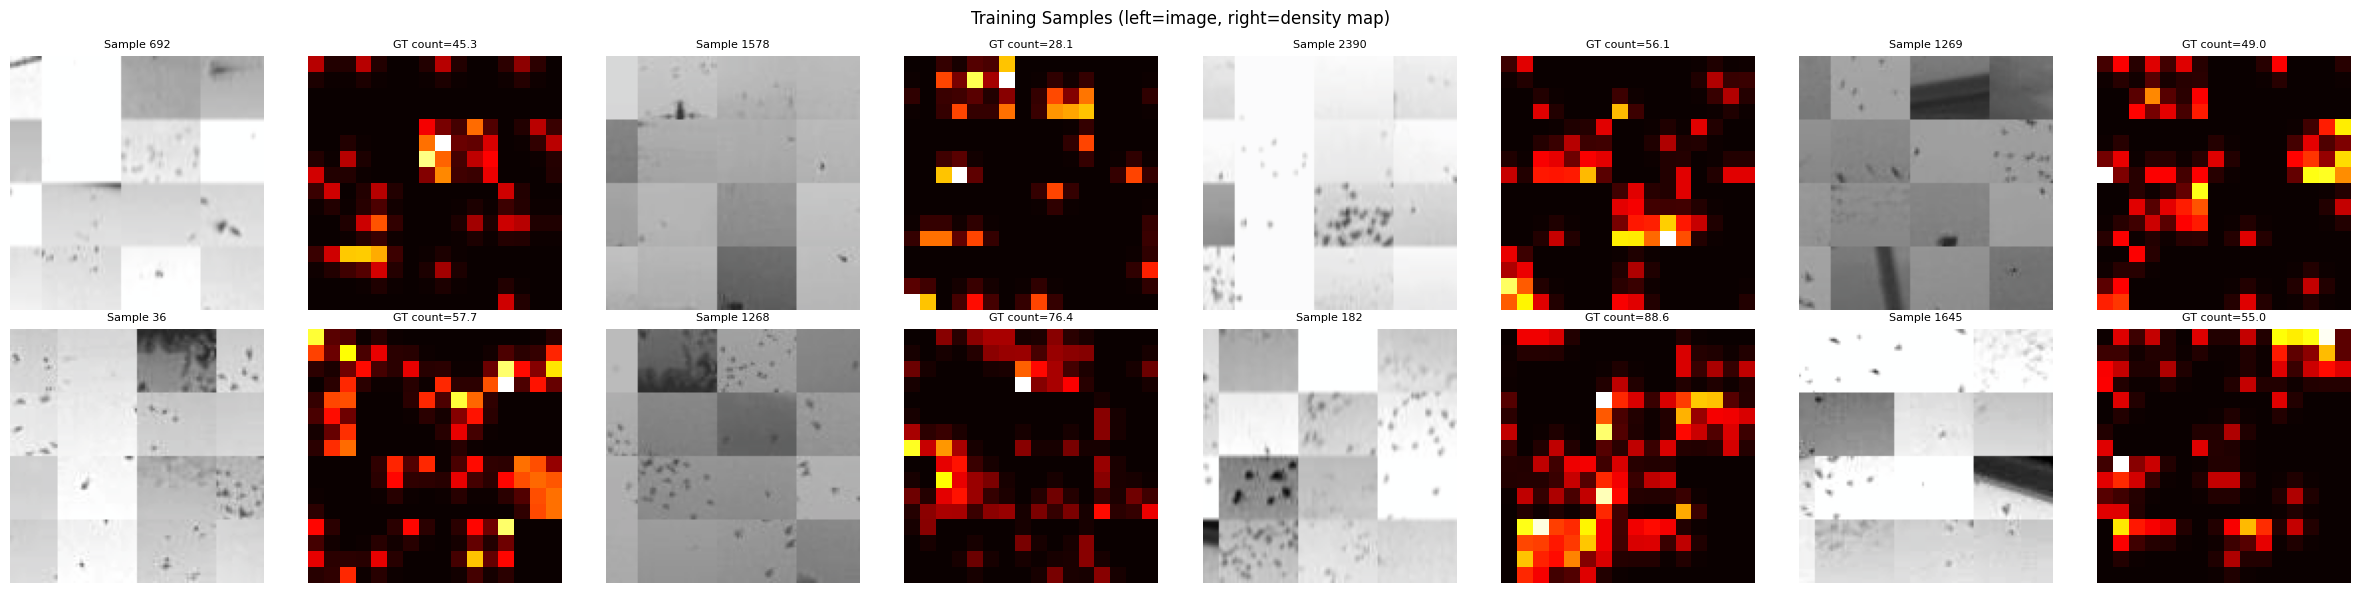

Saved to training_samples.png
Total samples:     2400
Zero-bat samples:  0 (0.0%)
Mean count:        51.67
Max count:         128.04
Median count:      49.53
>15 bat samples:   2398 (99.9%)


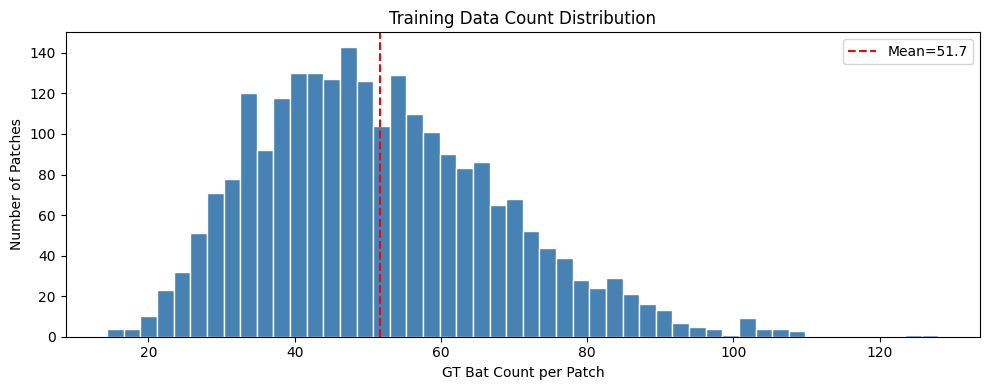

In [ ]:
# Make sure your dataset is already created
train_images  = "/content/drive/MyDrive/CPI_Folder_CSRNet/meshed/train/images"
test_images   = "/content/drive/MyDrive/CPI_Folder_CSRNet/meshed/test/images"
train_density = "/content/drive/MyDrive/CPI_Folder_CSRNet/meshed/train/density"
test_density  = "/content/drive/MyDrive/CPI_Folder_CSRNet/meshed/test/density"

train_ds = BatDensityDataset(train_images, train_density, train=True,  crop_size=128)
test_ds  = BatDensityDataset(test_images,  test_density,  train=False, crop_size=128)


visualize_training_samples(train_ds, num_samples=8, cols=4)
visualize_count_distribution(train_ds)

# Bounding Boxes


In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

# Global variables for drawing
drawing = False
roi = None  # (x1, y1, x2, y2)


from google.colab.patches import cv2_imshow
import cv2

def get_frame_with_grid(video_path, frame_number=0, grid_spacing=50):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        raise RuntimeError("Could not read frame")

    h, w = frame.shape[:2]
    print(f"Frame size: {w}w x {h}h")

    for x in range(0, w, grid_spacing):
        cv2.line(frame, (x, 0), (x, h), (0, 255, 0), 1)
        cv2.putText(frame, str(x), (x+2, 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 255, 0), 1)

    for y in range(0, h, grid_spacing):
        cv2.line(frame, (0, y), (w, y), (0, 255, 0), 1)
        cv2.putText(frame, str(y), (2, y+12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 255, 0), 1)

    cv2_imshow(frame)

def predict_frame(frame_bgr, model, img_tf, device, patch_size=128, stride=128):
    img_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    total_count = 0.0
    density_full = np.zeros((h//8, w//8), dtype=np.float32)

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img_rgb[y:y+patch_size, x:x+patch_size]
            patch_t = img_tf(Image.fromarray(patch)).unsqueeze(0).to(device)
            with torch.no_grad():
                pred = model(patch_t)
            patch_density = torch.relu(pred).squeeze().cpu().numpy()
            total_count += float(patch_density.sum())
            dy, dx = y//8, x//8
            ph, pw = patch_size//8, patch_size//8
            density_full[dy:dy+ph, dx:dx+pw] += patch_density

    return total_count, density_full


def preview_roi(video_path, x1, y1, x2, y2, frame_number=0):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        raise RuntimeError("Could not read frame")

    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2_imshow(frame)


def predict_video_with_roi(video_path, model, img_tf, device,
                           x1, y1, x2, y2,
                           patch_size=128, stride=128):
    """Run inference only within a manually specified ROI."""

    print(f"ROI set: ({x1}, {y1}) -> ({x2}, {y2})")

    cap = cv2.VideoCapture(video_path)
    frame_counts = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Crop to ROI
        roi_frame = frame[y1:y2, x1:x2]

        # Run sliding window only on the ROI
        count, density = predict_frame(roi_frame, model, img_tf, device, patch_size, stride)
        frame_counts.append(count)

        frame_idx += 1
        if frame_idx % 30 == 0:
            print(f"Frame {frame_idx} | count={count:.1f}")

    cap.release()
    print(f"Done. {frame_idx} frames processed.")
    print(f"Mean count: {sum(frame_counts)/len(frame_counts):.1f}")
    print(f"Max count:  {max(frame_counts):.1f}")
    return frame_counts

def preview_roi(video_path, x1, y1, x2, y2, frame_number=0):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()

    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2_imshow(frame)

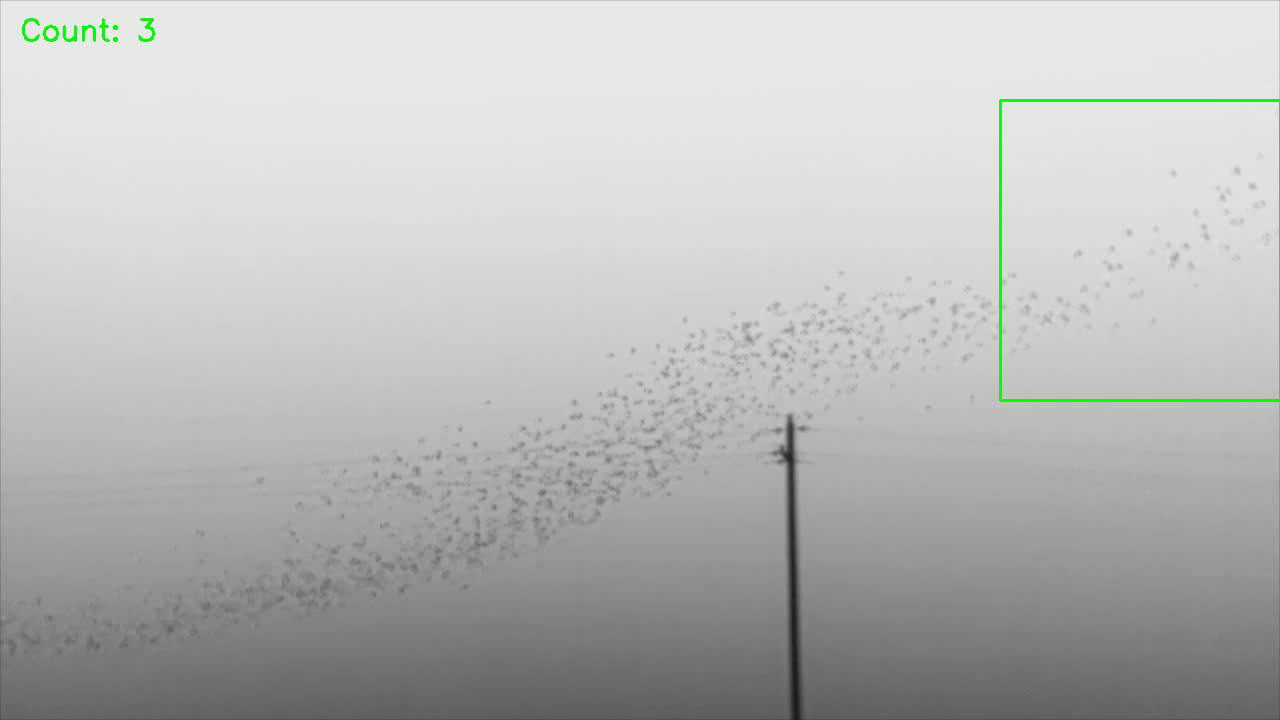

In [ ]:
DRIVE      = "/content/drive/MyDrive"
BASE       = f"{DRIVE}/CPI_Folder_CSRNet"

preview_roi(f"{BASE}/video/output.mp4", x1=1000, y1=100, x2=1280, y2=400)

In [ ]:
# Step 1: view grid to find coordinates
import cv2
import torch
import numpy as np
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image as PILImage

DRIVE      = "/content/drive/MyDrive"
BASE       = f"{DRIVE}/CPI_Folder_CSRNet"


def predict_video_density_overlay(
    video_path, model, img_tf, device,
    x1=1000, y1=100, x2=1280, y2=400,
    output_path=None
):
    if output_path is None:
        output_path = str(Path(video_path).parent / "density_overlay.mp4")

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    roi_w = x2 - x1
    roi_h = y2 - y1
    out_w = roi_w * 2
    out_h = roi_h

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (out_w, out_h))

    model.eval()
    colormap = plt.get_cmap("hot")

    frame_idx = 0
    with torch.no_grad():
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Crop ROI and convert to PIL RGB for img_tf
            roi = frame[y1:y2, x1:x2]
            roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
            roi_pil = PILImage.fromarray(roi_rgb)

            # Run inference
            tensor = img_tf(roi_pil).unsqueeze(0).to(device)
            pred = model(tensor)
            density = torch.relu(pred[0, 0]).cpu().numpy()
            count = density.sum()

            # Normalize and apply colormap
            d_norm = density / (density.max() + 1e-6)
            d_colored = (colormap(d_norm) * 255).astype(np.uint8)[:, :, :3]
            d_colored = cv2.cvtColor(d_colored, cv2.COLOR_RGB2BGR)
            d_resized = cv2.resize(d_colored, (roi_w, roi_h), interpolation=cv2.INTER_NEAREST)

            # Overlay text
            cv2.putText(d_resized, f"Count: {count:.1f}", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
            cv2.putText(d_resized, f"Frame: {frame_idx}", (10, 65),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 1)

            # Side by side
            roi_bgr = cv2.cvtColor(np.array(roi_pil), cv2.COLOR_RGB2BGR)
            combined = np.concatenate([roi_bgr, d_resized], axis=1)
            writer.write(combined)

            frame_idx += 1
            if frame_idx % 50 == 0:
                print(f"Processed {frame_idx}/{total_frames} frames")

    cap.release()
    writer.release()
    print(f"✓ Saved density overlay video → {output_path}")
    return output_path


# Run it
output_video = predict_video_density_overlay(
    f"{BASE}/video/output.mp4",
    model=model, img_tf=img_tf, device=device,
    x1=1000, y1=100, x2=1280, y2=400,
)

In [ ]:
import cv2
import numpy as np
import torch
import pandas as pd
from pathlib import Path
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.cm as cm



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CSRNet(load_imagenet_frontend=False)  # False since we're loading our own weights
ckpt  = torch.load("/content/drive/MyDrive/CPI_Folder_CSRNet/csrnet_meshed_best.pth", map_location=device)
model.load_state_dict(ckpt["model"])
model.to(device)
model.eval()

img_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


def compute_flux_roi(
    video_path, model, img_tf, device,
    roi_x=400, roi_y=400,
    roi_w=320, roi_h=384,
    output_csv=None,
    output_video=None,
):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    DENSITY_SCALE = 8
    PATCH_W, PATCH_H = 160, 128

    DM_W = roi_w // DENSITY_SCALE  # 40
    DM_H = roi_h // DENSITY_SCALE  # 48
    mid_col = DM_W // 2            # 20

    n_cols = roi_w // PATCH_W      # 2
    n_rows = roi_h // PATCH_H      # 3

    model.eval()
    colormap = plt.get_cmap("hot")

    if output_video:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(output_video, fourcc, fps, (roi_w * 2, roi_h))

    def get_roi_density(roi_gray):
        density = np.zeros((DM_H, DM_W), dtype=np.float32)
        for row in range(n_rows):
            for col in range(n_cols):
                px = col * PATCH_W
                py = row * PATCH_H
                patch = roi_gray[py:py+PATCH_H, px:px+PATCH_W]
                pil_patch = PILImage.fromarray(patch).convert("RGB")
                tensor = img_tf(pil_patch).unsqueeze(0).to(device)
                with torch.no_grad():
                    pred = model(tensor)
                    patch_dm = torch.relu(pred[0, 0]).cpu().numpy()
                dy = row * (PATCH_H // DENSITY_SCALE)
                dx = col * (PATCH_W // DENSITY_SCALE)
                density[dy:dy+16, dx:dx+20] = patch_dm
        return density

    def make_video_frame(roi_bgr, density, flow_u, flux, cumulative_flux, frame_count):
        d_norm = density / (density.max() + 1e-6)
        d_colored = (colormap(d_norm) * 255).astype(np.uint8)[:, :, :3]
        d_colored = cv2.cvtColor(d_colored, cv2.COLOR_RGB2BGR)
        d_resized = cv2.resize(d_colored, (roi_w, roi_h), interpolation=cv2.INTER_NEAREST)
        overlay = cv2.addWeighted(roi_bgr, 0.5, d_resized, 0.5, 0)

        # Draw counting line at middle column
        line_x = mid_col * DENSITY_SCALE
        cv2.line(overlay, (line_x, 0), (line_x, roi_h), (0, 255, 0), 2)

        # Draw flow arrows along counting line
        if flow_u is not None:
            for y in range(0, roi_h, 20):
                u = float(flow_u[y, line_x])
                end_x = int(np.clip(line_x + u * 3, 0, roi_w))
                color = (0, 255, 0) if u > 0 else (0, 0, 255)
                cv2.arrowedLine(overlay, (line_x, y), (end_x, y), color, 1, tipLength=0.3)

        cv2.putText(overlay, f"Count: {frame_count:.1f}",     (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
        cv2.putText(overlay, f"Flux:  {flux:.2f} bats/frame", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
        cv2.putText(overlay, f"Total: {cumulative_flux:.0f}", (10, 75), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)

        return np.concatenate([roi_bgr, overlay], axis=1)

    # ── Main loop ──────────────────────────────────────────────
    results = []
    prev_roi_gray = None
    cumulative_flux = 0.0
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        roi_bgr  = frame[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
        roi_gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)

        density = get_roi_density(roi_gray)
        frame_count = density.sum()

        flux = 0.0
        flow_u_full = None

        if prev_roi_gray is not None:
            flow = cv2.calcOpticalFlowFarneback(
                prev_roi_gray, roi_gray, None,
                pyr_scale=0.5, levels=3, winsize=15,
                iterations=3, poly_n=5, poly_sigma=1.2, flags=0
            )
            flow_u_full = flow[..., 0]  # (roi_h, roi_w)

            # Downsample flow to density map resolution
            flow_u_dm = cv2.resize(flow_u_full, (DM_W, DM_H))

            # Flux at middle column
            density_col = density[:, mid_col]
            flow_col    = flow_u_dm[:, mid_col]
            flux = float(np.sum(density_col * flow_col))
            cumulative_flux += flux

            if frame_idx in [50, 100, 350]:
                print(f"\n--- Frame {frame_idx} ---")
                print(f"density_col: sum={density_col.sum():.3f} max={density_col.max():.3f}")
                print(f"flow_col: mean={flow_col.mean():.2f} max={flow_col.max():.2f}")
                print(f"flux={flux:.3f} cumulative={cumulative_flux:.1f}")

        results.append({
            "frame_idx":       frame_idx,
            "timestamp_s":     frame_idx / fps,
            "frame_count":     frame_count,
            "flux_per_frame":  flux,
            "cumulative_flux": cumulative_flux,
        })

        if output_video:
            vis = make_video_frame(roi_bgr, density, flow_u_full,
                                   flux, cumulative_flux, frame_count)
            writer.write(vis)

        if frame_idx % 50 == 0:
            print(f"Frame {frame_idx}/{total_frames} | "
                  f"count={frame_count:.1f} | "
                  f"flux={flux:.2f} | "
                  f"total={cumulative_flux:.1f}")

        prev_roi_gray = roi_gray
        frame_idx += 1

    cap.release()
    if output_video:
        writer.release()
        print(f"✓ Video saved → {output_video}")

    df = pd.DataFrame(results)
    if output_csv:
        df.to_csv(output_csv, index=False)
        print(f"✓ CSV saved → {output_csv}")

    print(f"\n{'='*40}")
    print(f"Total frames: {frame_idx}")
    print(f"Population estimate: {cumulative_flux:.1f} bats")
    print(f"{'='*40}")
    return df

# Run
df = compute_flux_roi(
    video_path=f"{BASE}/video/Y2.2.3[Val2].mov",
    model=model,
    img_tf=img_tf,
    device=device,
    roi_x= 480, roi_y=34,
    roi_w=160, roi_h=256, # divisible by 160 and 128
    output_csv=f"{BASE}/flux_roi_results.csv",
    output_video=f"{BASE}/flux_roi_overlay.mp4",
)

In [ ]:
import cv2

DRIVE      = "/content/drive/MyDrive"
BASE       = f"{DRIVE}/CPI_Folder_CSRNet"

def get_frame_pixel_info(video_path, frame_num=0):
    cap = cv2.VideoCapture(video_path)

    # Get video info
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"Video info:")
    print(f"  Resolution: {frame_w} x {frame_h}")
    print(f"  FPS: {fps}")
    print(f"  Total frames: {total_frames}")
    print(f"  Duration: {total_frames/fps:.1f}s")

    # Seek to frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print("Could not read frame")
        return

    # Save frame with grid overlay so you can identify coordinates
    overlay = frame.copy()

    # Draw grid every 100px
    for x in range(0, frame_w, 100):
        cv2.line(overlay, (x, 0), (x, frame_h), (0, 255, 0), 1)
        cv2.putText(overlay, str(x), (x+2, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0), 1)

    for y in range(0, frame_h, 100):
        cv2.line(overlay, (0, y), (frame_w, y), (0, 255, 0), 1)
        cv2.putText(overlay, str(y), (2, y+15), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0), 1)

    cv2.imwrite("/content/drive/MyDrive/CPI_Folder_CSRNet/frame_grid.jpg", overlay)
    print(f"\n✓ Saved frame {frame_num} with pixel grid → frame_grid.jpg")

get_frame_pixel_info(f"{BASE}/video/Y2.2.3[Val2].mov", frame_num=400)

Video info:
  Resolution: 640 x 512
  FPS: 29.97
  Total frames: 891
  Duration: 29.7s

✓ Saved frame 400 with pixel grid → frame_grid.jpg
